Quick notebook to test the generic Observatory implementation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import division

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.ticker import NullFormatter
#matplotlib.rcParams['savefig.dpi'] = 1.5 * matplotlib.rcParams['savefig.dpi']

import os, glob, time, sys, functools
import corner
import numpy as np

import scipy
import scipy.constants as sc
import scipy.integrate as si
import scipy.signal as ssig
import scipy.interpolate as scint
import scipy.linalg as sl

# from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
# import acor

In [3]:
import astropy.constants as const
import astropy.units as u

In [4]:
# import libstempo as T2
# from libstempo import toasim as LT
# from libstempo import plot as LP
# from libstempo import eccUtils as eu

# import enterprise
# from enterprise.pulsar import Pulsar
# from enterprise.signals import parameter
# from enterprise.signals import selections
# from enterprise.signals import signal_base
# import enterprise.signals.signal_base as base
# from enterprise.signals import white_signals
# from enterprise.signals import gp_signals
# from enterprise.signals import deterministic_signals
# from enterprise.signals import utils
# from enterprise import constants as const

# import enterprise_extensions as ee
# from enterprise_extensions import models, model_utils, blocks

In [5]:
import PhenomA as pa
import observatories as obs
import WaveformTools as wt
import WaveformTools_old as wto
import utils

In [6]:
muAres_snfile = 'strain_sens_ARES_instrument.txt'

In [7]:
muAres = obs.Observatory("muAres",1*u.yr,sens_curve=muAres_snfile)

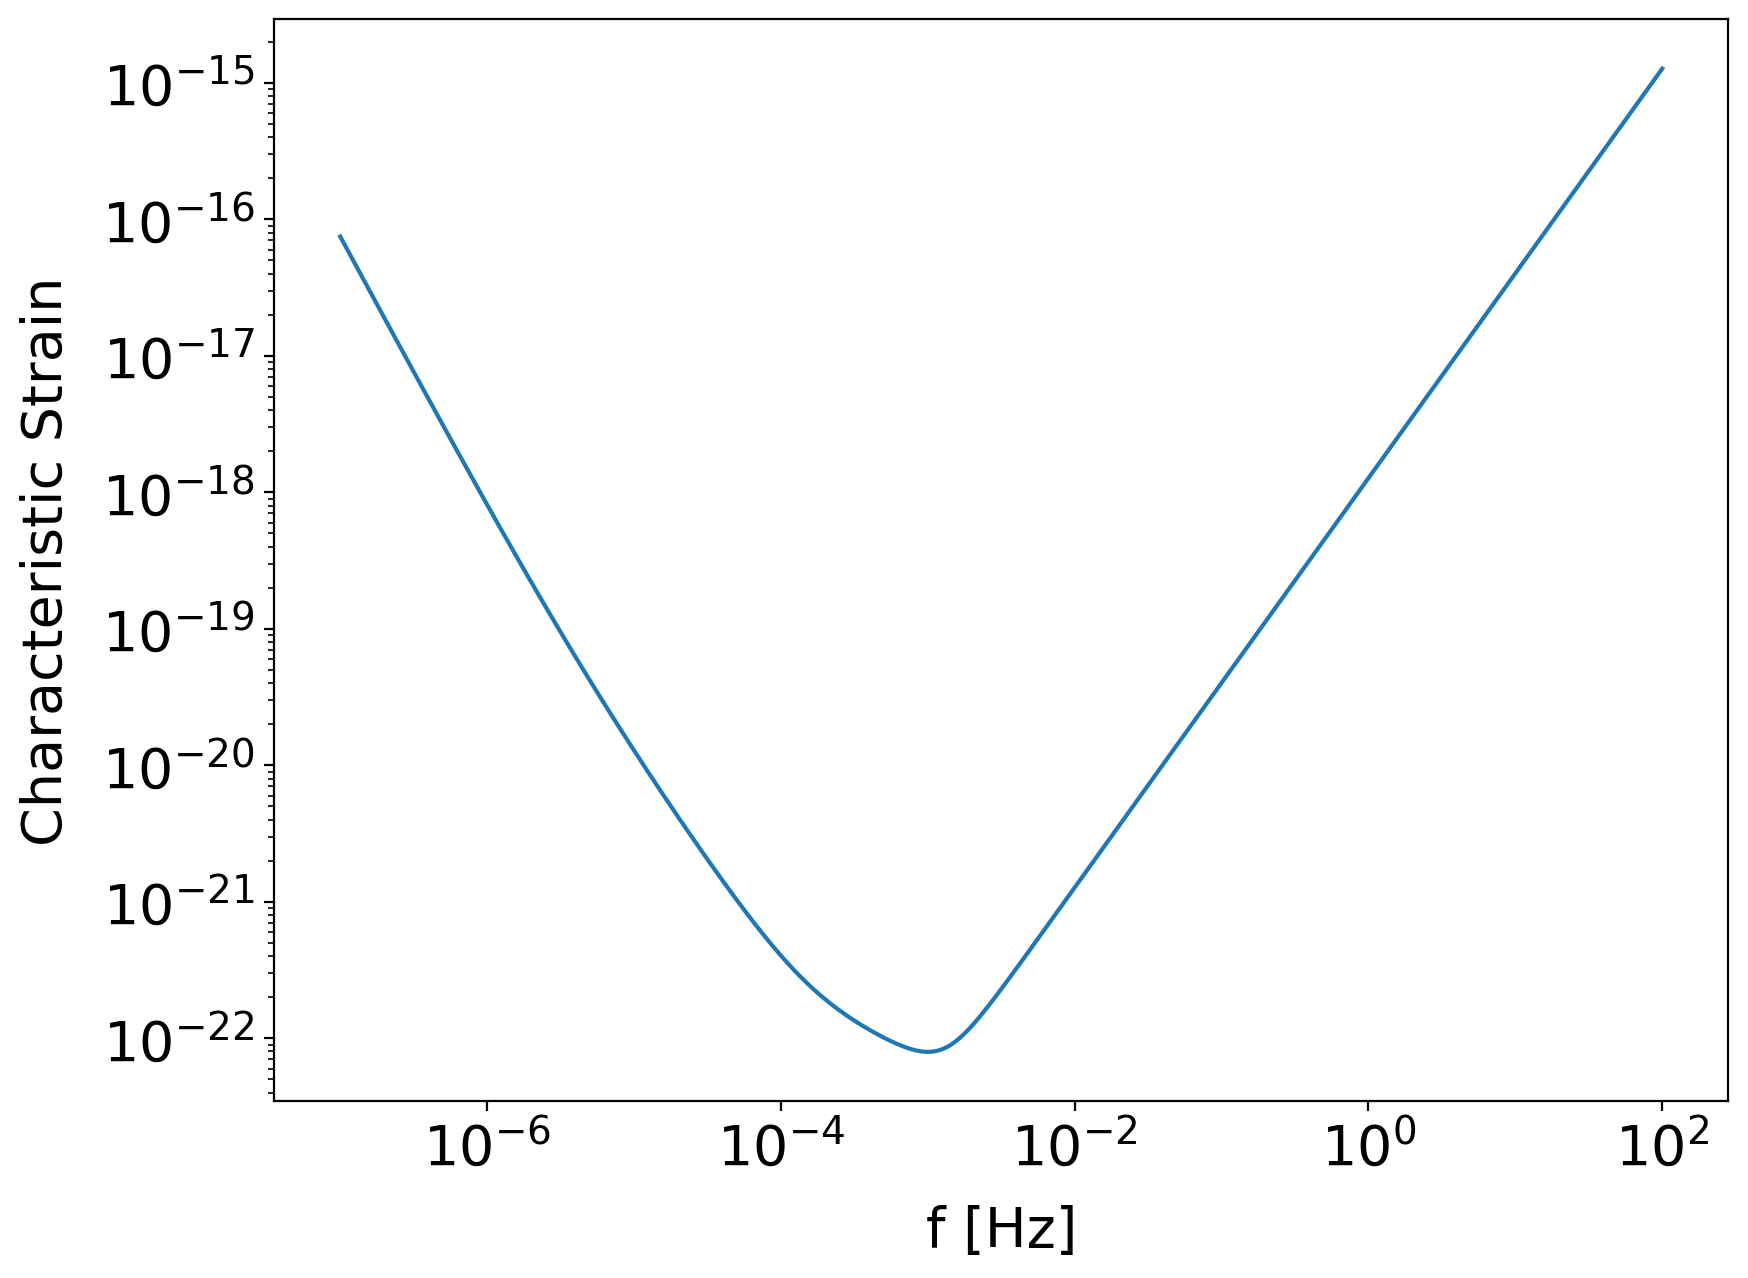

In [8]:
muAres.PlotSensitivityCurve()

In [9]:
binary = wt.Binary(1e8,1e8,z=0.5)
binary.f_start

Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc


In [10]:
T_merge = 1*u.yr
binary.T_merge = T_merge.to(u.s)

In [11]:
binary.SetFreqBounds(muAres)

In [12]:
freqs, hc = binary.CalcStrain(muAres)

11521.365464039302


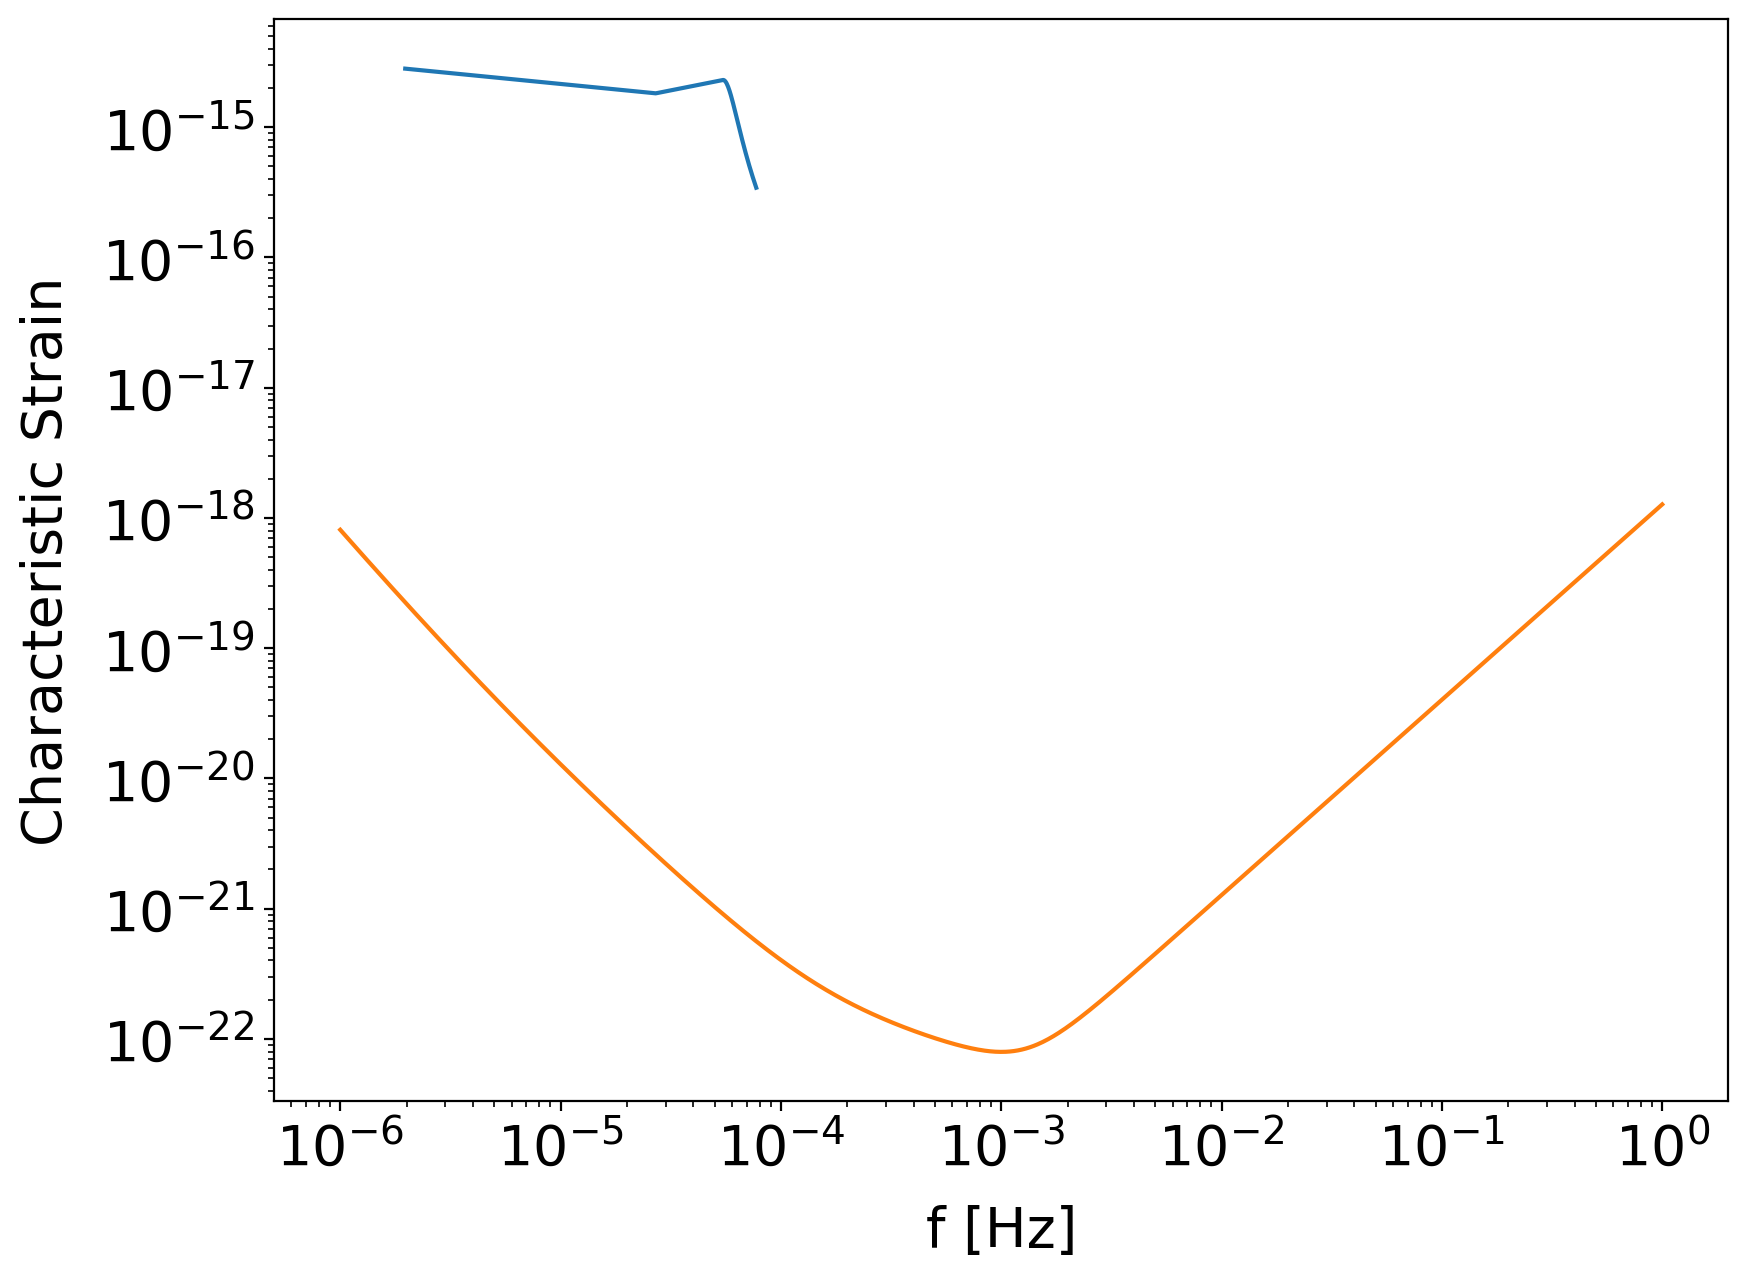

In [13]:
print(binary.CalcSNR(freqs, hc, muAres))
binary.PlotStrain(freqs, hc, muAres)

In [14]:
lisa = obs.LISA() 

In [15]:
binary = wt.Binary(1e8,1e8,z=0.5)
binary.f_start

Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc


In [16]:
T_merge = 1*u.yr
binary.T_merge = T_merge.to(u.s)

In [17]:
binary.SetFreqBounds(lisa)

In [18]:
freqs, hc = binary.CalcStrain(lisa)

604.8534238228257


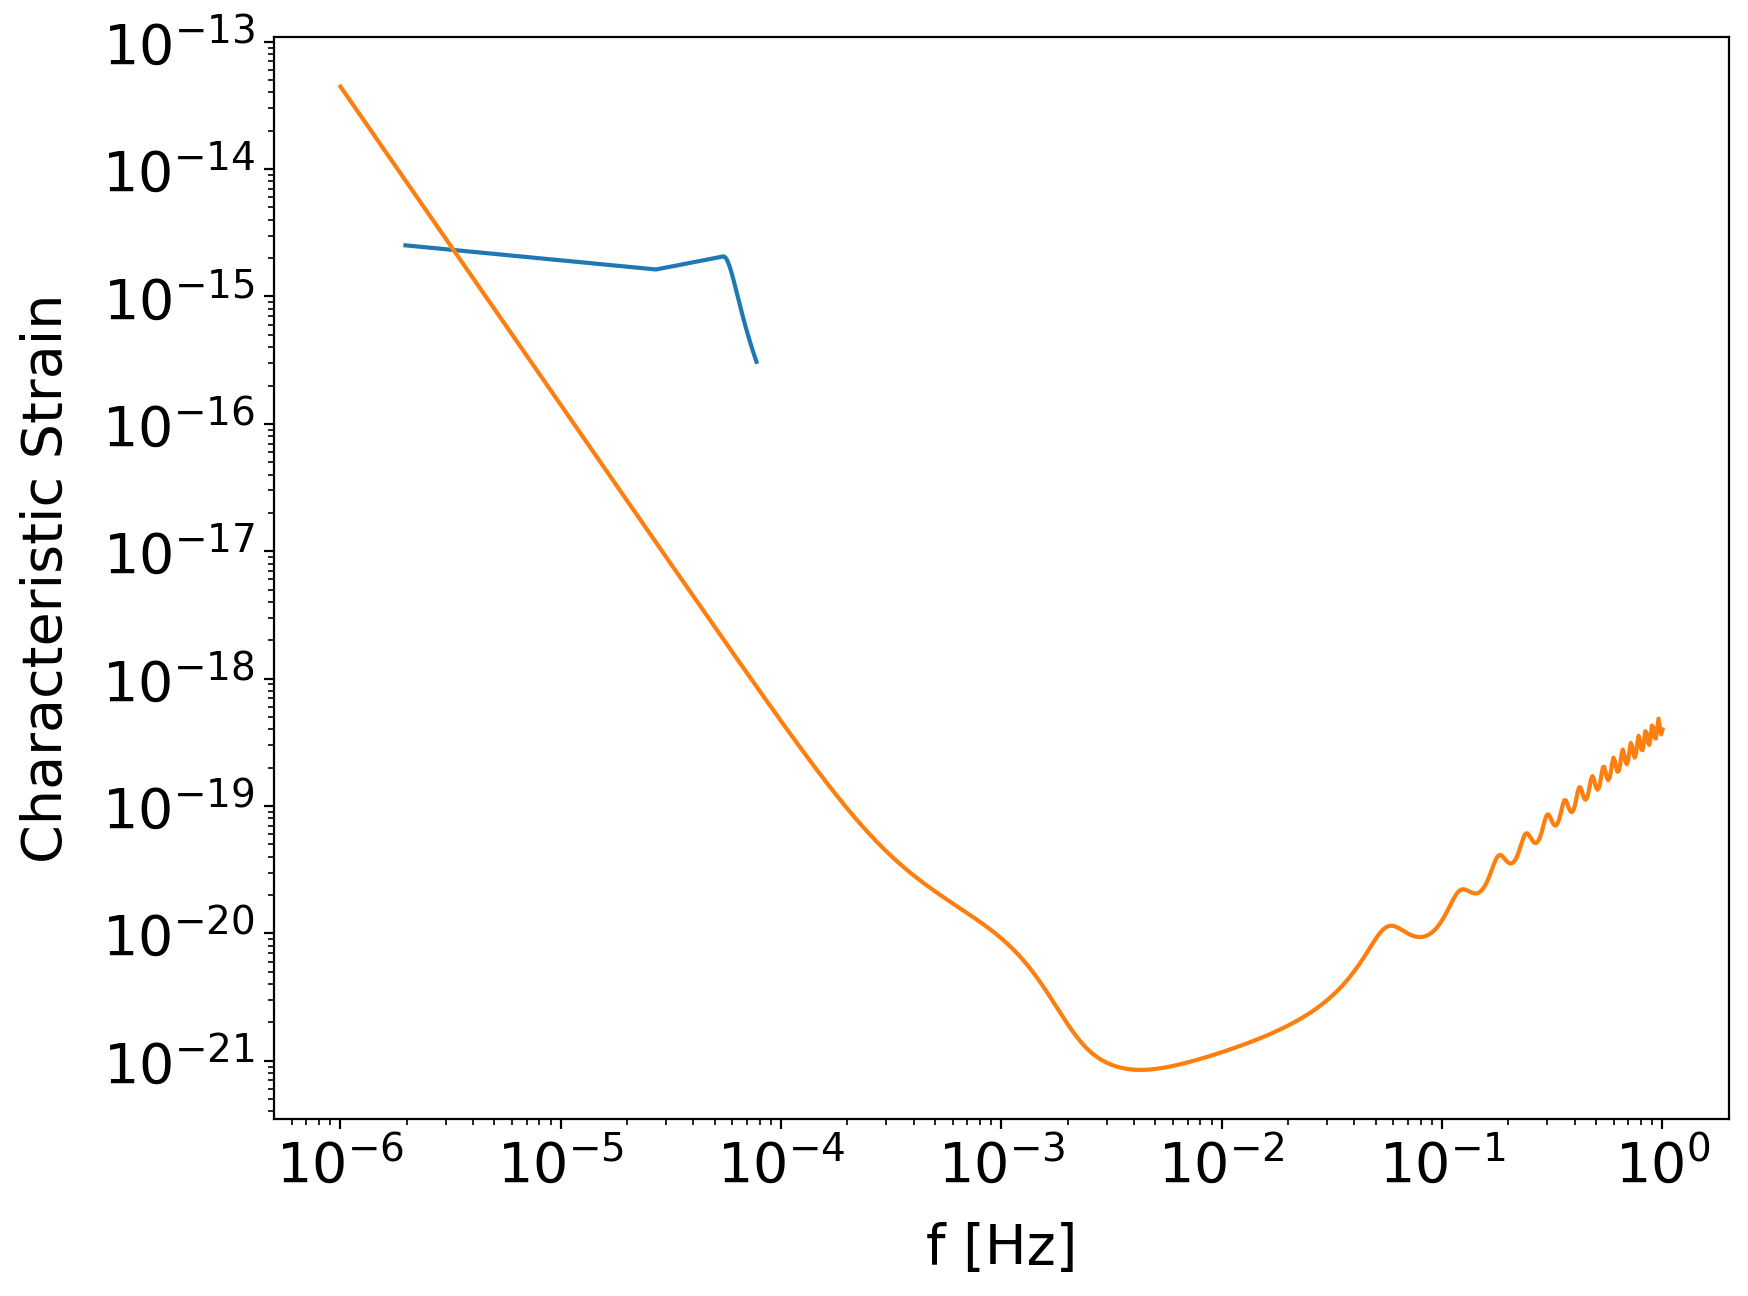

In [19]:
print(binary.CalcSNR(freqs, hc, lisa))
binary.PlotStrain(freqs, hc, lisa)

In [20]:
binary = wt.Binary(1e8,1e8,z=0.5)
binary.T_merge = T_merge.to(u.s)
binary.run_full_SNR_calc(muAres,T_merge)

Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc


11521.365464039302

In [21]:
amin = 1
amax = 10
a = np.arange(-1,12)

In [22]:
filt = (a > amin)*(a < amax)

In [23]:
res = 2.*filt
res[res==0] = np.inf

In [24]:
res

array([inf, inf, inf,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2., inf, inf])

In [38]:
kepler = obs.Astrometry("Kepler")

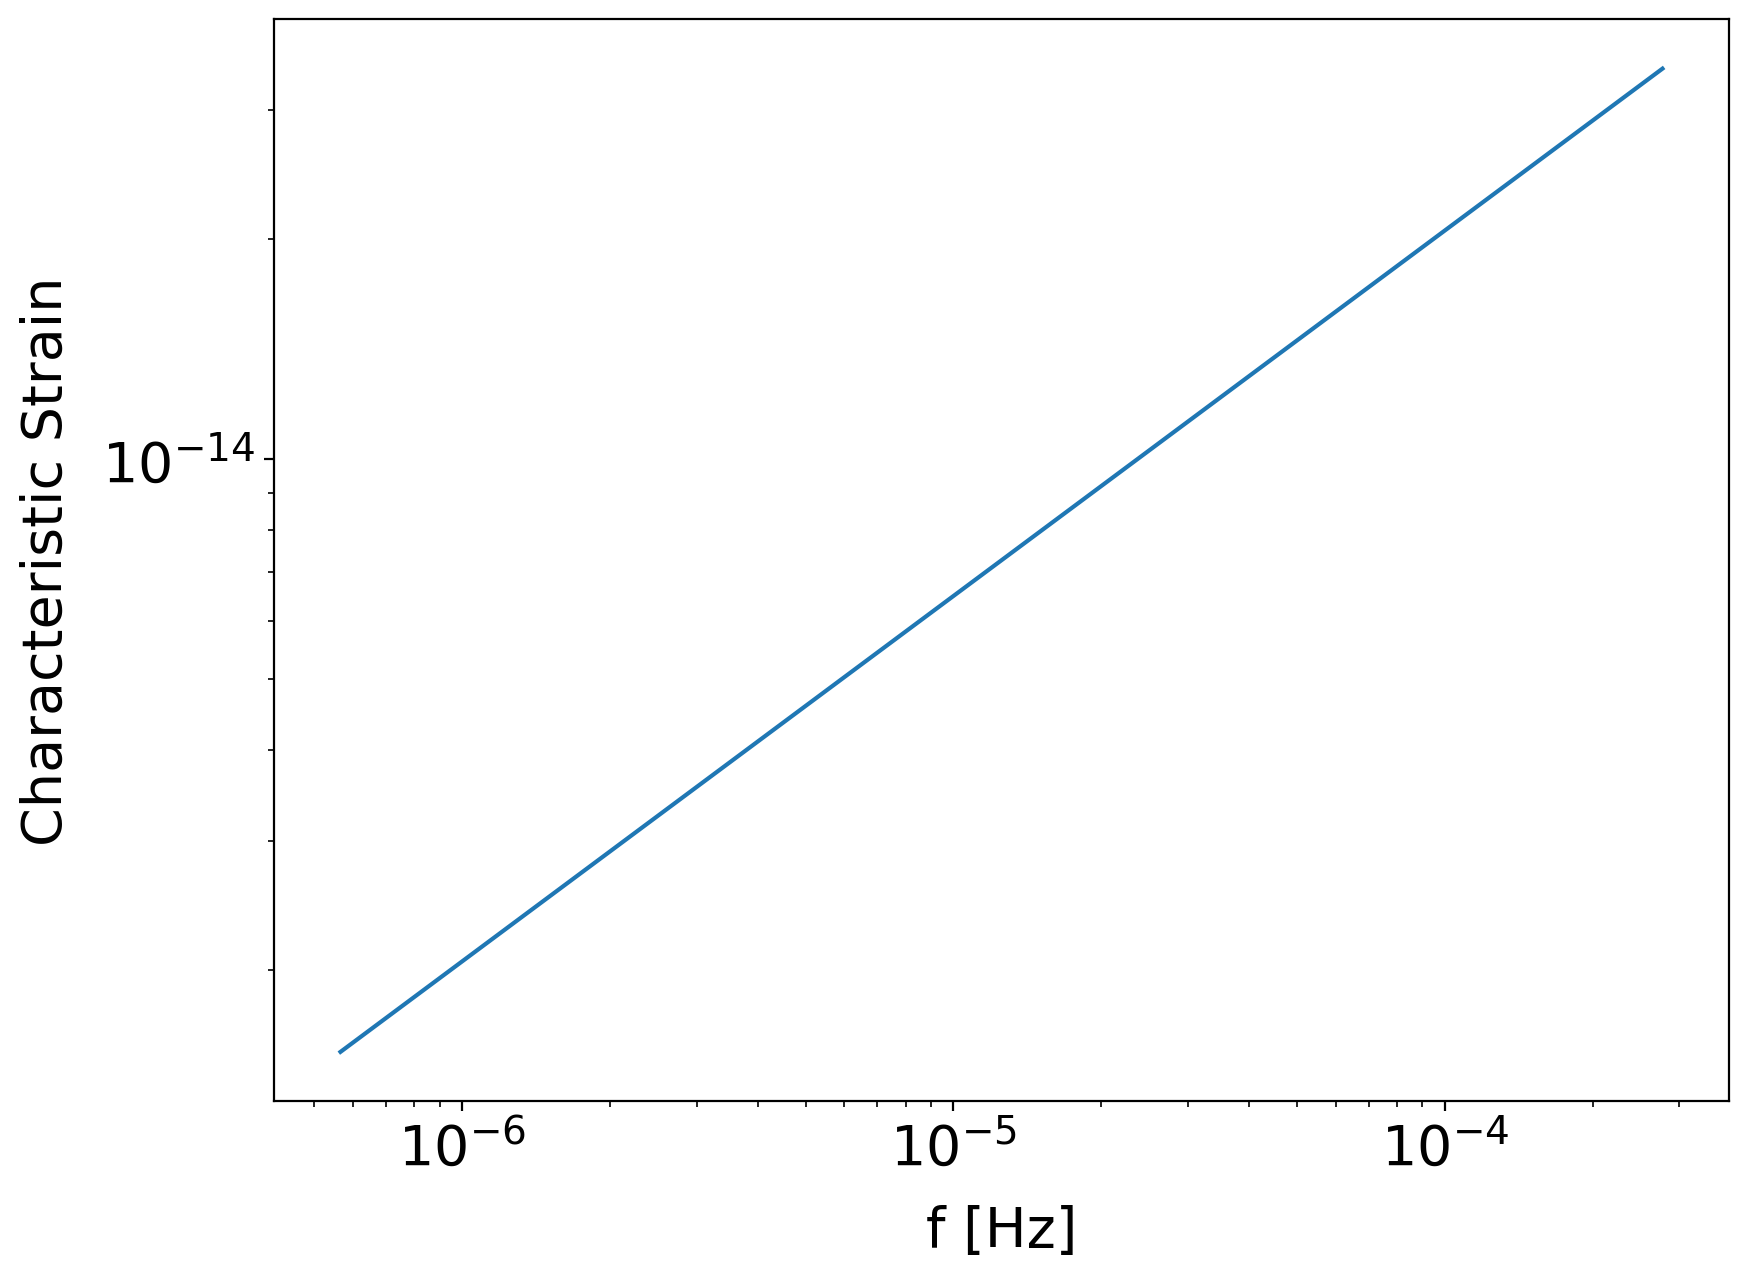

In [39]:
kepler.PlotSensitivityCurve()

In [40]:
binary = wt.Binary(1e8,1e8,z=0.5)
binary.f_start

Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc


In [41]:
T_merge = 1*u.yr
binary.T_merge = T_merge.to(u.s)

In [42]:
binary.SetFreqBounds(kepler)

In [43]:
freqs, hc = binary.CalcStrain(kepler)

0.002032095731525974


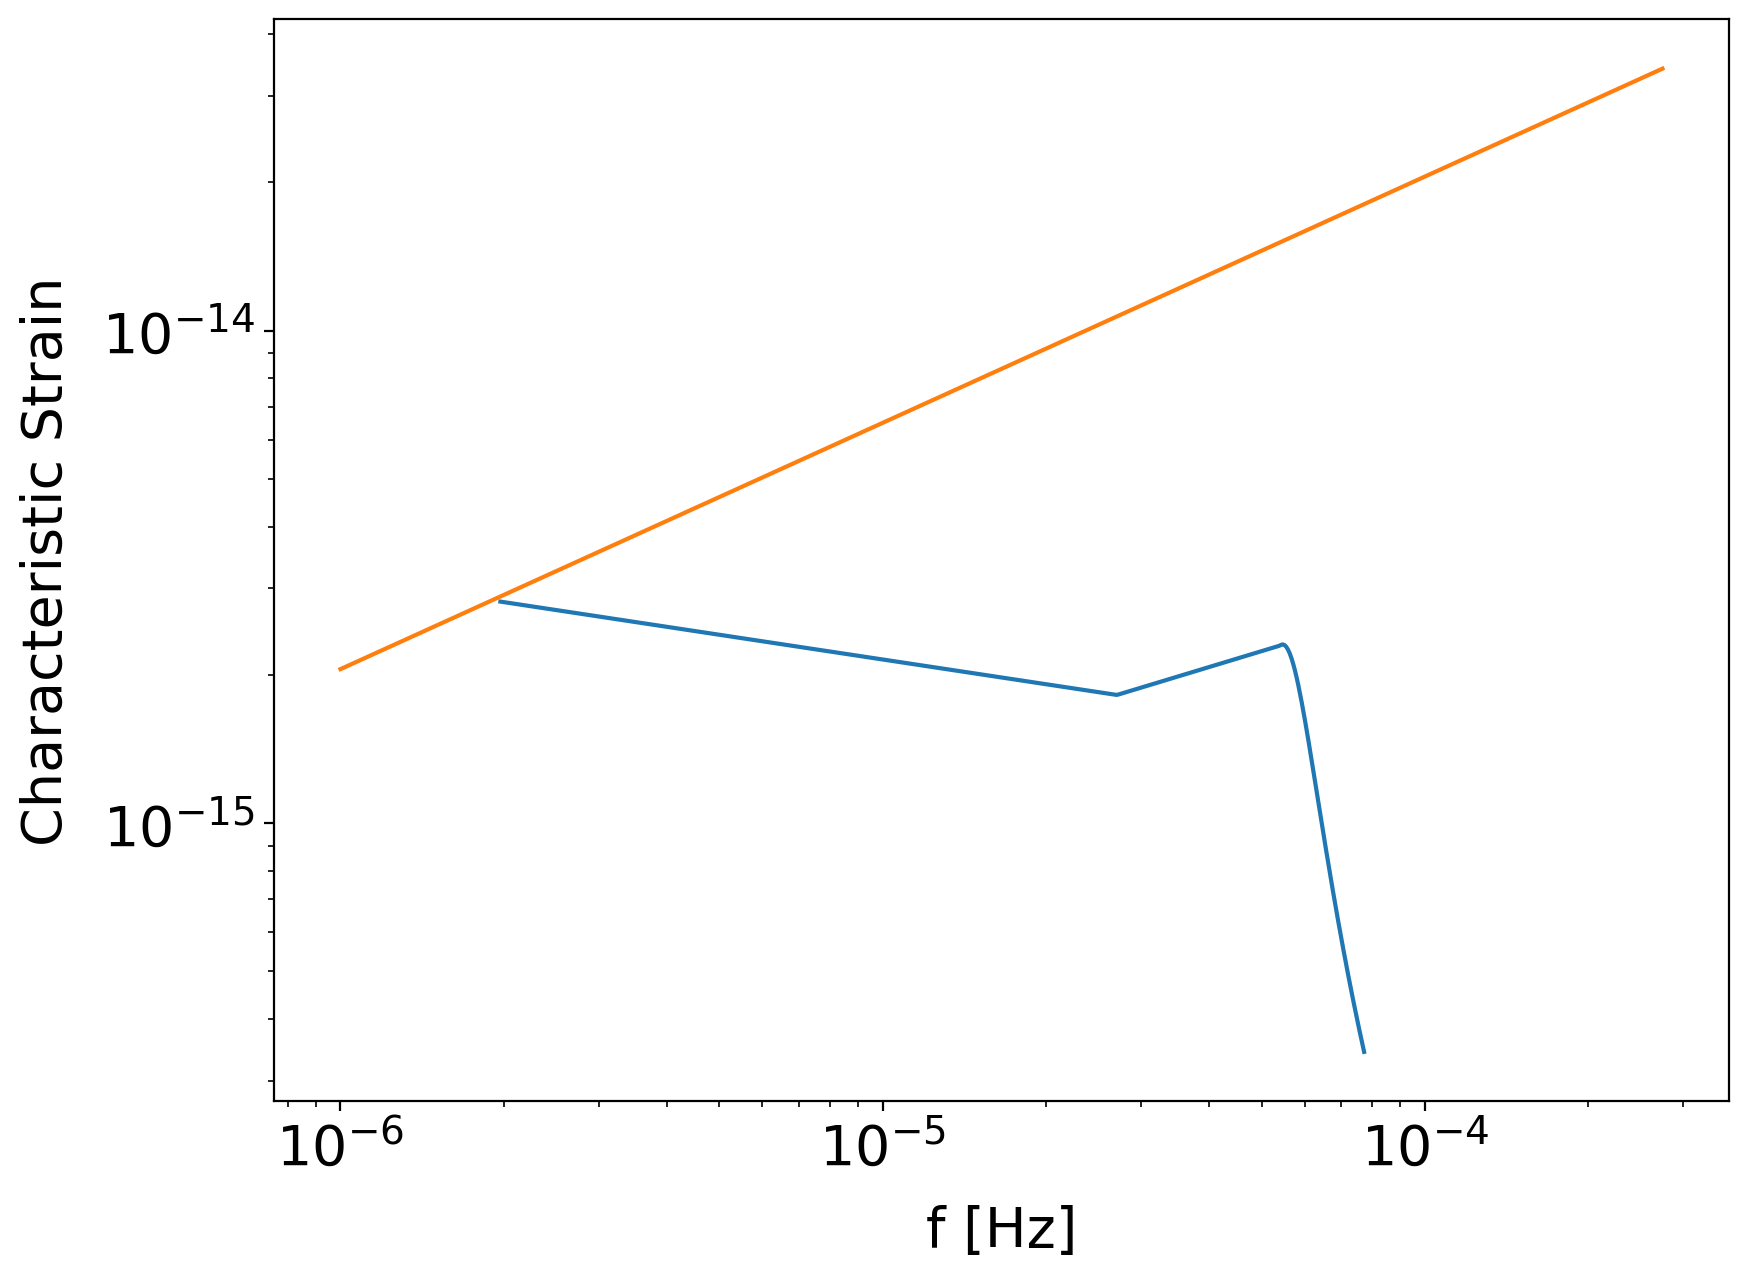

In [45]:
print(binary.CalcSNR(freqs, hc, kepler))
binary.PlotStrain(freqs, hc, kepler)

In [46]:
roman = obs.Astrometry("Roman")

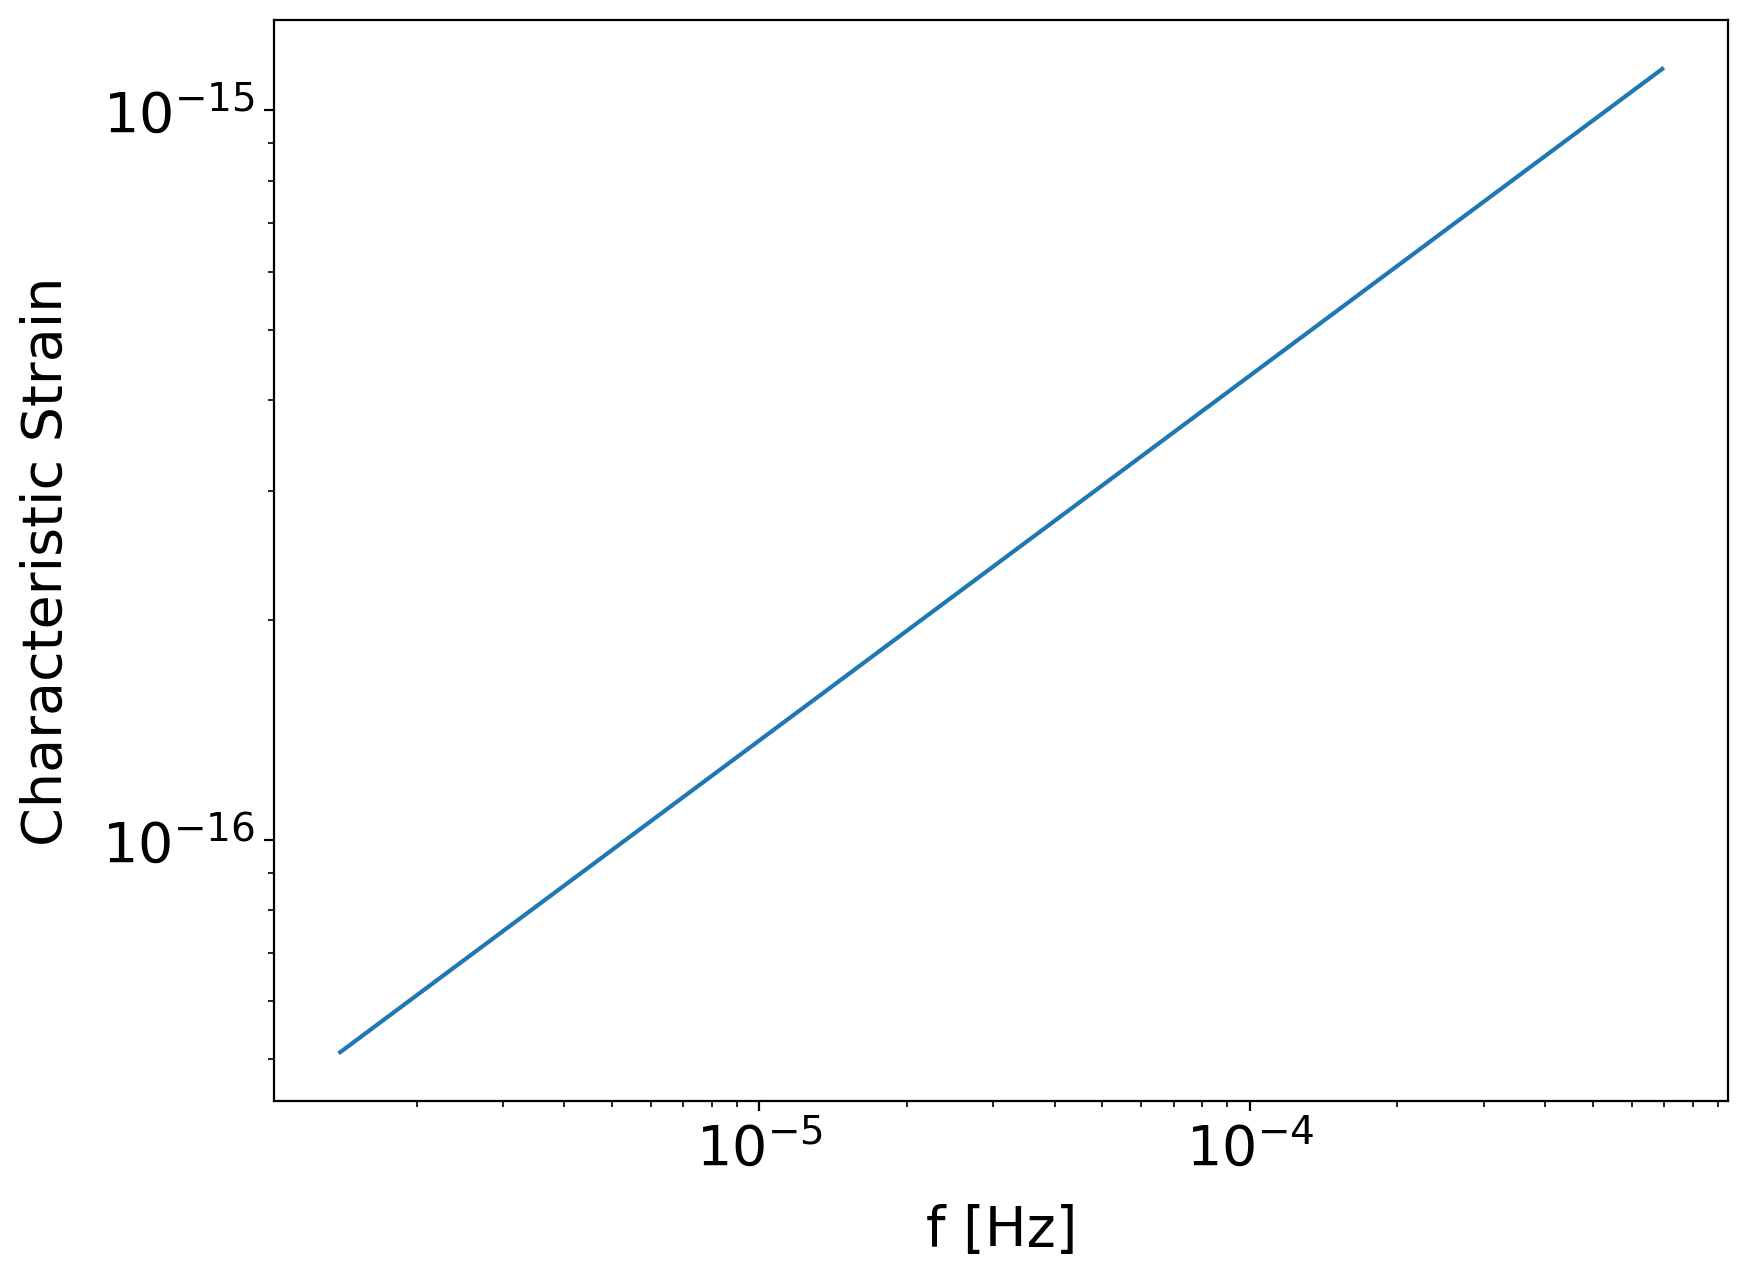

In [48]:
roman.PlotSensitivityCurve()

In [49]:
binary = wt.Binary(1e8,1e8,z=0.5)
binary.f_start

Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc


In [50]:
T_merge = 1*u.yr
binary.T_merge = T_merge.to(u.s)

In [51]:
binary.SetFreqBounds(roman)

In [52]:
freqs, hc = binary.CalcStrain(roman)

0.09660075390103995


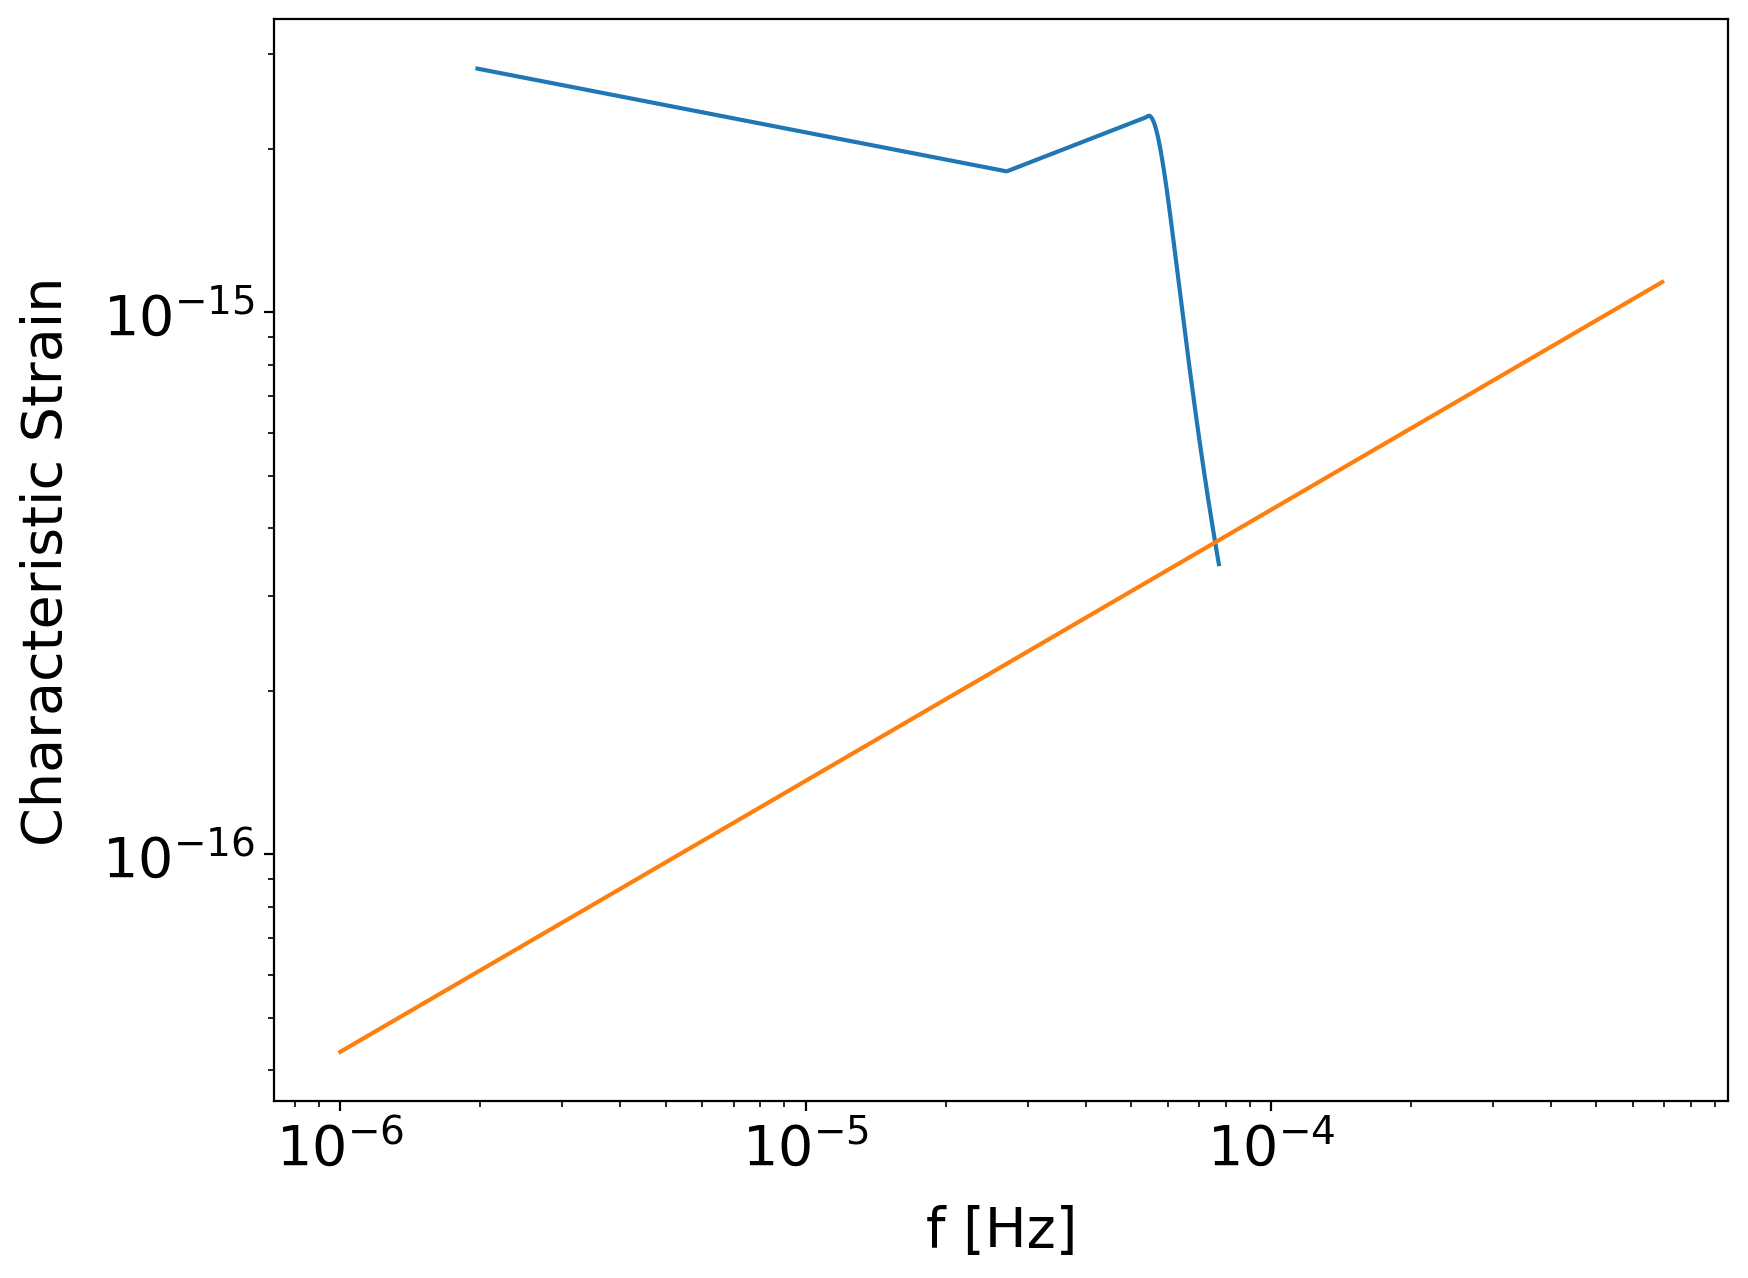

In [53]:
print(binary.CalcSNR(freqs, hc, roman))
binary.PlotStrain(freqs, hc, roman)

Nice. To the grid!